# Number Analizer with **DeepLearning** 🌀

## Data 📊

Using **idx2numpy** we can convert *ubyte* to *matrix*. 
We have 10k images to test and 60k images to triain

In [184]:
import idx2numpy
import numpy as np
import matplotlib.pyplot as plt

test_images = idx2numpy.convert_from_file('./Dataset/Original_dataset/t10k-images.idx3-ubyte')
test_labels = idx2numpy.convert_from_file('./Dataset/Original_dataset/t10k-labels.idx1-ubyte')
train_images = idx2numpy.convert_from_file('./Dataset/Original_dataset/train-images.idx3-ubyte')
train_labels = idx2numpy.convert_from_file('./Dataset/Original_dataset/train-labels.idx1-ubyte')

print(train_labels.shape)

(60000,)


Transform *uint8* to *float64*. The dimension of each image is 28x28 (matrix), but we change it to 784

In [185]:
X = train_images/255
print(type(train_labels[0]))
print(type(X[0,0,0]))
print(X.shape)

<class 'numpy.uint8'>
<class 'numpy.float64'>
(60000, 28, 28)


Using **MatplotLib** we can draw the numbers

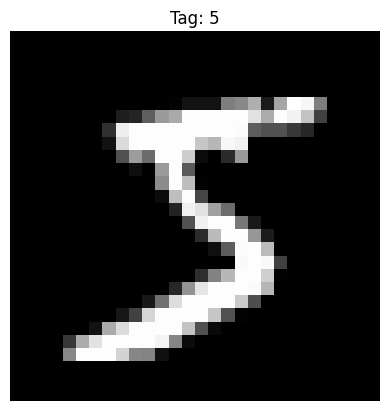

In [186]:
plt.imshow(X[0], cmap='gray')
plt.title(f"Tag: {train_labels[0]}")
plt.axis('off')
plt.show()

## Classes 📦

Abstract Layer class defining the common interface for all **layers** (init, forward, backward, update)

In [187]:
from abc import abstractmethod, ABC

In [188]:
class Layer(ABC):
    @abstractmethod
    def init(self): pass

    @abstractmethod
    def forward(self, x): pass

    @abstractmethod
    def backward(self, grad_output): pass

    @abstractmethod
    def update(self, lr): pass

**Deep dense layer**: initializes **weights W** (shape: input_size x output_size) and **biases B** (shape: 1 x output_size). Forward computes **X @ W + B**. Backward computes **gradients dW and dB** and returns **grad_input** for backpropagation. Includes **Adam optimizer variables** (mW, vW, mB, vB) with **bias-corrected updates** and **float64 precision** for numerical stability.

In [198]:
class Deep(Layer):
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size
        self.init()
        # Adam variables
        self.mW = np.zeros((input_size, output_size))
        self.vW = np.zeros((input_size, output_size))
        self.mB = np.zeros((1, output_size))
        self.vB = np.zeros((1, output_size))
        self.t = 0

    def init(self):
        self.W = 2 * np.random.rand(self.input_size, self.output_size) - 1
        self.B = np.random.rand(1, self.output_size)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.B

    def backward(self, grad_output):
        grad_input = grad_output @ self.W.T
        self.dW = self.x.T @ grad_output
        self.dB = np.sum(grad_output, axis=0, keepdims=True)
        return grad_input

    def update(self, lr, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.t += 1
        # Momentum
        self.mW = beta1 * self.mW + (1 - beta1) * self.dW
        self.mB = beta1 * self.mB + (1 - beta1) * self.dB
        # RMSP
        self.vW = beta2 * self.vW + (1 - beta2) * (self.dW ** 2)
        self.vB = beta2 * self.vB + (1 - beta2) * (self.dB ** 2)
        # Bias-corrected
        mW_hat = self.mW / (1 - beta1 ** self.t)
        mB_hat = self.mB / (1 - beta1 ** self.t)
        vW_hat = self.vW / (1 - beta2 ** self.t)
        vB_hat = self.vB / (1 - beta2 ** self.t)
        # Force float64 para estabilidad numérica
        self.W = self.W.astype(np.float64)
        self.B = self.B.astype(np.float64)
        # Update weights
        self.W -= lr * mW_hat / (np.sqrt(vW_hat) + epsilon)
        self.B -= lr * mB_hat / (np.sqrt(vB_hat) + epsilon)


**Activation layer**: applies a non-linear **activation function** to the input. Forward stores the input **x** and returns **func(x)**. Backward computes **grad_output * func_deriv(x)** to propagate gradients. No parameters, so **init and update are empty**.

In [190]:
class Activation(Layer):
    def __init__(self, func, func_deriv):
        self.func = func
        self.func_deriv = func_deriv
        self.x = None

    def init(self):
        pass

    def forward(self, x):
        self.x = x
        return self.func(x)

    def backward(self, grad_output):
        return grad_output * self.func_deriv(self.x)

    def update(self, lr):
        pass

In [191]:
class Model:
    def __init__(self, layers):
        self.sequential = layers

    def forward(self, x):
        for layer in self.sequential:
            x = layer.forward(x)
        return x

    def backward(self, grad_output):
        for layer in reversed(self.sequential):
            grad_output = layer.backward(grad_output)
        return grad_output

    def update(self, lr):
        for layer in self.sequential:
            layer.update(lr)


## Implementation 🛠️

**Activation functions**: 
- **ReLU** returns max(0, x) and its derivative is 1 where x > 0, else 0.  
- **Softmax** computes normalized exponentials along each row for probabilities, derivative approximated as s * (1 - s) (note: full Jacobian ignored for simplicity in backprop).

In [192]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / np.sum(e_x, axis=1, keepdims=True)

def softmax_deriv(x):
    s = softmax(x)
    return s * (1 - s)

**Training utilities**:  
- **train_step**: performs a single forward pass, computes error, runs backward pass, updates weights, and prints **accuracy**.  
- **train_loop**: iterates over batches of data and applies **train_step** to each.  
- **accuracy**: computes the fraction of correctly predicted labels by comparing argmax of predictions vs. true labels.

In [193]:
def train_step(model, x, y, lr):
    y_pred = model.forward(x)
    error = y_pred - y 
    model.backward(error)
    model.update(lr)
    acc = accuracy(y_pred, y)
    print("Accuracy:", acc)

def train_loop(model, data, lr):
    for x_batch, y_batch in data:
        train_step(model, x_batch, y_batch, lr)

def accuracy(y_pred, y_real):
    goods = np.sum(np.argmax(y_pred, axis=1) == np.argmax(y_real, axis=1))
    acc = goods / len(y_real)
    return acc


**Data preparation and model setup**:  
- **Reshape X**: flattens each 28x28 image into a vector of size 784.  
- **One-hot encode Y**: converts labels into **one-hot vectors** with 10 classes.  
- **Batch creation**: splits dataset into batches of size **500**.  
- **Model definition**: a simple **feedforward neural network** with one hidden layer (100 neurons, ReLU) and an output layer (10 neurons, softmax).  
- **Training loop**: runs for 15 epochs with **learning rate lr=0.001** and calls **train_loop** on each epoch.

In [194]:
X = X.reshape(X.shape[0], 28 * 28)

Y = np.zeros((train_labels.shape[0], 10))
for i, label in enumerate(train_labels):
    Y[i, label] = 1

batch_size = 500
num_samples = X.shape[0]

data = []
for i in range(0, num_samples, batch_size):
    x_batch = X[i:i + batch_size]
    y_batch = Y[i:i + batch_size]
    data.append((x_batch, y_batch))

model = Model([
    Deep(784, 100),           
    Activation(relu, relu_deriv),
    Deep(100, 10),
    Activation(softmax, softmax_deriv)
])

lr = 0.001
epochs = 15
epoch = 0

while epoch < epochs:
    print("Epoch:", epoch + 1)
    train_loop(model, data, lr)
    epoch += 1

Epoch: 1
Accuracy: 0.062
Accuracy: 0.08
Accuracy: 0.078
Accuracy: 0.058
Accuracy: 0.066
Accuracy: 0.076
Accuracy: 0.072
Accuracy: 0.07
Accuracy: 0.066
Accuracy: 0.062
Accuracy: 0.07
Accuracy: 0.076
Accuracy: 0.084
Accuracy: 0.092
Accuracy: 0.098
Accuracy: 0.07
Accuracy: 0.074
Accuracy: 0.076
Accuracy: 0.098
Accuracy: 0.076
Accuracy: 0.082
Accuracy: 0.112
Accuracy: 0.062
Accuracy: 0.102
Accuracy: 0.106
Accuracy: 0.096
Accuracy: 0.12
Accuracy: 0.116
Accuracy: 0.114
Accuracy: 0.096
Accuracy: 0.128
Accuracy: 0.094
Accuracy: 0.116
Accuracy: 0.102
Accuracy: 0.136
Accuracy: 0.092
Accuracy: 0.106
Accuracy: 0.112
Accuracy: 0.134
Accuracy: 0.122
Accuracy: 0.114
Accuracy: 0.16
Accuracy: 0.128
Accuracy: 0.116
Accuracy: 0.164
Accuracy: 0.14
Accuracy: 0.16
Accuracy: 0.154
Accuracy: 0.12
Accuracy: 0.132
Accuracy: 0.12
Accuracy: 0.134
Accuracy: 0.138
Accuracy: 0.164
Accuracy: 0.162
Accuracy: 0.136
Accuracy: 0.156
Accuracy: 0.156
Accuracy: 0.132
Accuracy: 0.136
Accuracy: 0.158
Accuracy: 0.14
Accuracy: 

## Test 📈

1 sola imagen

**Single-sample prediction**:  
- **Reshape input**: ensures the image vector has shape **(1, 784)**.  
- **Forward pass**: compute output using the **model.forward** method.  
- **Class prediction**: returns the **index of the max probability** as the predicted class.

In [195]:
def predict_single(model, image_flat):
    x = image_flat.reshape(1, -1)
    y_pred = model.forward(x)
    predicted_class = np.argmax(y_pred, axis=1)[0]
    return predicted_class

In [196]:
def show_prediction_random(model, test_images, test_labels):
    idx = np.random.randint(0, len(test_images))
    image = test_images[idx]
    true_label = test_labels[idx]
    x = (image / 255).reshape(784)
    y_pred = model.forward(x.reshape(1, -1))
    pred = np.argmax(y_pred, axis=1)[0]

    plt.imshow(image, cmap="gray")
    plt.title(f"Predicted: {pred} | Real: {true_label} | Index: {idx}")
    plt.axis("off")
    plt.show()

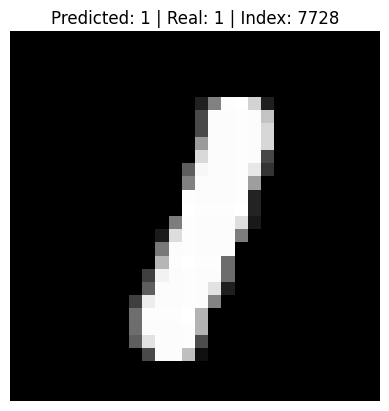

In [197]:
show_prediction_random(model, test_images, test_labels)

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(test_labels, test_images)

ModuleNotFoundError: No module named 'sklearn'